# CellChat

In [1]:
# install.packages("Seurat")

# # install.packages("devtools")
# BiocManager::install("BiocNeighbors")
# # devtools::install_github("hadley/devtools")

# install.packages('NMF')
# devtools::install_github("jokergoo/circlize")
# devtools::install_github("jokergoo/ComplexHeatmap")

# devtools::install_github("sqjin/CellChat")

In [2]:
# # in py console
# pip install umap-learn

https://htmlpreview.github.io/?https://github.com/sqjin/CellChat/blob/master/tutorial/CellChat-vignette.html

In [3]:
library(Seurat)
# library(BPCells)
library(ggplot2)
library(patchwork)
library(dplyr)
library(magrittr)
library(Matrix)
library(future)
library(ComplexHeatmap)
library(pheatmap)
library(grid)
library(circlize)
library(CellChat)
library(ggalluvial)
library(igraph)
library(NMF)
library(RColorBrewer)
library(viridis)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.26.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effo

In [4]:
# Multicore CPU usage activation - Future

library(future)

plan("multicore", workers = 24) # Mac Pro 6.1
# plan(workers = 36) # iMac Pro 1.1
# plan("multicore", workers = 8) # 4 core Intel CPU and M1 have 8 threads
# plan("multicore", workers = 12) # 6 core Intel CPU has 12 threads
# plan("multicore", workers = 10) # 10 core M1 Pro CPU has 10 threads

# Set RAM Size to 3/4 of total RAM

options(future.globals.maxSize = 64000 * 1024^2) # Mac Pros have 64 Gb
# options(future.globals.maxSize = 12000 * 1024^2) # iMacs and MacBook Pros have 16 Gb

future.seed = NULL # Removes future-generated statistical errors

In [5]:
# Seurat

Seurat <- readRDS('Seurat_For_CellChat.rds')

In [6]:
DefaultAssay(Seurat) <- "SCT"

In [8]:
Idents(Seurat) <- "CellTypeDeep"

table(Idents(Seurat))


Neutrophil-like Erythroid Cells        APC-like Erythroid Cells 
                            418                             103 
   NK-cell-like Erythroid Cells         Erythroid Cells (Fetal) 
                            252                            5752 
       Erythroid Cells (Mature)                  Megakaryocytes 
                           8352                             564 
                    Neutrophils                       uNK-cells 
                           2341                             625 
                        T-cells                       Monocytes 
                           1105                             597 
                 Hofbauer Cells              Macrophages (APCs) 
                           1438                            1913 
     Macrophages (Inflammatory)        Macrophages (Remodeling) 
                           1316                            1201 
           Glandular Epithelium                    Decidua Late 
                        

In [9]:
seurat_list <- SplitObject(Seurat, split.by = "BioGroup")

run_cellchat_standard <- function(s_obj) {
  s_obj@meta.data$CellTypeDeep <- droplevels(s_obj@meta.data$CellTypeDeep)
  
  chat <- createCellChat(s_obj, group.by = "CellTypeDeep", assay = "SCT")
  
  chat@DB <- CellChatDB.mouse 
  
  chat <- subsetData(chat)
  chat <- identifyOverExpressedGenes(chat)
  chat <- identifyOverExpressedInteractions(chat)

  chat@idents <- droplevels(chat@idents)
  
  chat <- computeCommunProb(chat)
  chat <- filterCommunication(chat, min.cells = 10)
  chat <- computeCommunProbPathway(chat)
  chat <- aggregateNet(chat)
  return(chat)
}

chat_list <- lapply(seurat_list, run_cellchat_standard)

CellChat <- mergeCellChat(chat_list, add.names = names(chat_list))

[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Neutrophil-like Erythroid Cells APC-like Erythroid Cells NK-cell-like Erythroid Cells Erythroid Cells (Fetal) Erythroid Cells (Mature) Megakaryocytes Neutrophils uNK-cells T-cells Monocytes Hofbauer Cells Macrophages (APCs) Macrophages (Inflammatory) Macrophages (Remodeling) Glandular Epithelium Decidua Late Decidua Early Myofibroblasts Fibroblasts Labyrinth Trophoblast Spongiotrophoblasts Glycogen Trophoblasts Giant Cells Syncytiotrophoblasts Labyrinthine Mesenchyme Pericytes Endothelial Cells 
Issue identified!! Please check the official Gene Symbol of the following genes:  
 H2-BI H2-Ea-ps 
triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2026-03-29 00:43:42]"
[1] ">>> CellChat inference

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



In [12]:
saveRDS(CellChat,'CellChat.rds')

An object of class CellChat created from a merged object with multiple datasets 
 893 signaling genes.
 43489 cells. 
CellChat analysis of single cell RNA-seq data! 

In [5]:
CellChat <- readRDS('CellChat.rds')

In [6]:
CellChat

An object of class CellChat created from a merged object with multiple datasets 
 893 signaling genes.
 43489 cells. 
CellChat analysis of single cell RNA-seq data! 

In [7]:
library(NMF)
library(ggalluvial)

In [8]:
dataset_names <- names(CellChat@net)

print(dataset_names) 

comparisons_to_make <- list(
  "Pregnancy E12.5" = c("E12.5 Syn", "E12.5 Semi-Allo"),
  "Pregnancy E19.5" = c("E19.5 Syn", "E19.5 Semi-Allo"),
  "Gestation Syn"        = c("E12.5 Syn", "E19.5 Syn"),
  "Gestation Semi-Allo"   = c("E12.5 Semi-Allo", "E19.5 Semi-Allo")
)

comparison_indices <- lapply(comparisons_to_make, function(comp) {
  match(comp, dataset_names)
})

print(comparison_indices)

[1] "E12.5 Semi-Allo" "E12.5 Syn"       "E19.5 Semi-Allo" "E19.5 Syn"      
$`Pregnancy E12.5`
[1] 2 1

$`Pregnancy E19.5`
[1] 4 3

$`Gestation Syn`
[1] 2 4

$`Gestation Semi-Allo`
[1] 1 3



In [10]:
library(ComplexHeatmap)
library(CellChat)

message("1. Lifting CellChat to align all cell populations...")
# Extract the master list of all cell types across all 4 groups
all_cell_types <- levels(CellChat@idents$joint)

# Pad missing cell populations with 0s so all matrices match
CellChat <- liftCellChat(CellChat, group.new = all_cell_types)

message("2. Re-applying the Centrality Calclation...")
for (dataset_name in names(CellChat@netP)) {
  temp_chat <- CellChat 
  temp_chat@netP <- CellChat@netP[[dataset_name]]
  temp_chat@net  <- CellChat@net[[dataset_name]]
  
  if (is.list(CellChat@idents)) {
    temp_chat@idents <- CellChat@idents[[dataset_name]]
  }
  
  temp_chat <- netAnalysis_computeCentrality(temp_chat, slot.name = "netP")
  CellChat@netP[[dataset_name]]$centr <- temp_chat@netP$centr
}

1. Lifting CellChat to align all cell populations...

The CellChat object will be lifted up using the cell labels Neutrophil-like Erythroid Cells, APC-like Erythroid Cells, NK-cell-like Erythroid Cells, Erythroid Cells (Fetal), Erythroid Cells (Mature), Megakaryocytes, Neutrophils, uNK-cells, T-cells, Monocytes, Hofbauer Cells, Macrophages (APCs), Macrophages (Inflammatory), Macrophages (Remodeling), Glandular Epithelium, Decidua Late, Decidua Early, Myofibroblasts, Fibroblasts, Labyrinth Trophoblast, Spongiotrophoblasts, Glycogen Trophoblasts, Giant Cells, Syncytiotrophoblasts, Labyrinthine Mesenchyme, Pericytes, Endothelial Cells



Update slots object@net, object@netP, object@idents in dataset  E12.5 Semi-Allo 
Update slots object@net, object@netP, object@idents in dataset  E12.5 Syn 
Update slots object@net, object@netP, object@idents in dataset  E19.5 Semi-Allo 
Update slots object@net, object@netP, object@idents in dataset  E19.5 Syn 


2. Re-applying the Centrality Calclation...

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_sapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore". [future ‘future_sapply-1’ (0b2c80d236cc48ee5e9c56ee38740b4e-1); on 0b2c80d236cc48ee5e9c56ee38740b4e@MacBook-Pro-Roman.local<49444>]”
Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_sapply-2’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that

R_zmq_msg_send errno: 4 strerror: Interrupted system call


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_sapply-17’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore". [future ‘future_sapply-17’ (0b2c80d236cc48ee5e9c56ee38740b4e-40); on 0b2c80d236cc48ee5e9c56ee38740b4e@MacBook-Pro-Roman.local<49444>]”
Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_sapply-18’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are

In [45]:
# PAIRWISE DIFFERENTIAL HEATMAPS

while (!is.null(dev.list())) dev.off() # Clear plotting space

for (comp_name in names(comparison_indices)) {
  idx <- comparison_indices[[comp_name]]
  message(sprintf("Generating Pairwise Heatmaps for: %s", comp_name))
  
  # Count Heatmap
  ht_count <- netVisual_heatmap(CellChat, comparison = idx, measure = "count")
  jpeg(sprintf("HM_nComms_Count_%s.jpeg", comp_name), width = 20, height = 18.5, units = "cm", res = 600)
  draw(ht_count, heatmap_legend_side = "right", annotation_legend_side = "right")
  dev.off()
  
  # Weight Heatmap
  ht_weight <- netVisual_heatmap(CellChat, comparison = idx, measure = "weight")
  jpeg(sprintf("HM_nComms_Weight_%s.jpeg", comp_name), width = 20.5, height = 18.5, units = "cm", res = 600)
  draw(ht_weight, heatmap_legend_side = "right", annotation_legend_side = "right")
  dev.off()
}
message("Pairwise heatmaps saved!")

Generating Pairwise Heatmaps for: Pregnancy E12.5

Do heatmap based on a merged object 


Do heatmap based on a merged object 


Generating Pairwise Heatmaps for: Pregnancy E19.5

Do heatmap based on a merged object 


Do heatmap based on a merged object 


Generating Pairwise Heatmaps for: Gestation Syn

Do heatmap based on a merged object 


Do heatmap based on a merged object 


Generating Pairwise Heatmaps for: Gestation Semi-Allo

Do heatmap based on a merged object 


Do heatmap based on a merged object 


Pairwise heatmaps saved!



In [16]:
file_w <- 9   # (22cm)
file_h <- 14  # (28cm)

hm_w <- 17   
hm_h <-27  
f_size <- 10 

my_palette <- "RdPu" 

for (dataset_name in names(CellChat@netP)) {
  message(sprintf("Generating Incoming/Outgoing Heatmaps for: %s", dataset_name))
  
  temp_chat <- CellChat 
  temp_chat@netP <- CellChat@netP[[dataset_name]]
  temp_chat@net  <- CellChat@net[[dataset_name]]
  
  if (is.list(CellChat@idents)) {
    temp_chat@idents <- CellChat@idents[[dataset_name]]
  }
  
  temp_chat <- netAnalysis_computeCentrality(temp_chat, slot.name = "netP")

  jpeg(sprintf("CellChat_Inc_Heatmap_%s.jpg", dataset_name), width = file_w, height = file_h, units = "in", res = 500)
  
  p_in <- netAnalysis_signalingRole_heatmap(temp_chat, 
                                            pattern = "incoming", 
                                            width = hm_w, 
                                            height = hm_h, 
                                            font.size = f_size,
                                            color.heatmap = my_palette) # Changed here
  print(p_in)
  dev.off()

  jpeg(sprintf("CellChat_Out_Heatmap_%s.jpg", dataset_name), width = file_w, height = file_h, units = "in", res = 500)
  
  p_out <- netAnalysis_signalingRole_heatmap(temp_chat, 
                                             pattern = "outgoing", 
                                             width = hm_w, 
                                             height = hm_h, 
                                             font.size = f_size,
                                             color.heatmap = my_palette) # Changed here
  print(p_out)
  dev.off()
}

message("Heatmaps are done!")

Generating Incoming/Outgoing Heatmaps for: E12.5 Semi-Allo

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_sapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore". [future ‘future_sapply-1’ (0b2c80d236cc48ee5e9c56ee38740b4e-309); on 0b2c80d236cc48ee5e9c56ee38740b4e@MacBook-Pro-Roman.local<49444>]”
Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_sapply-2’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. 

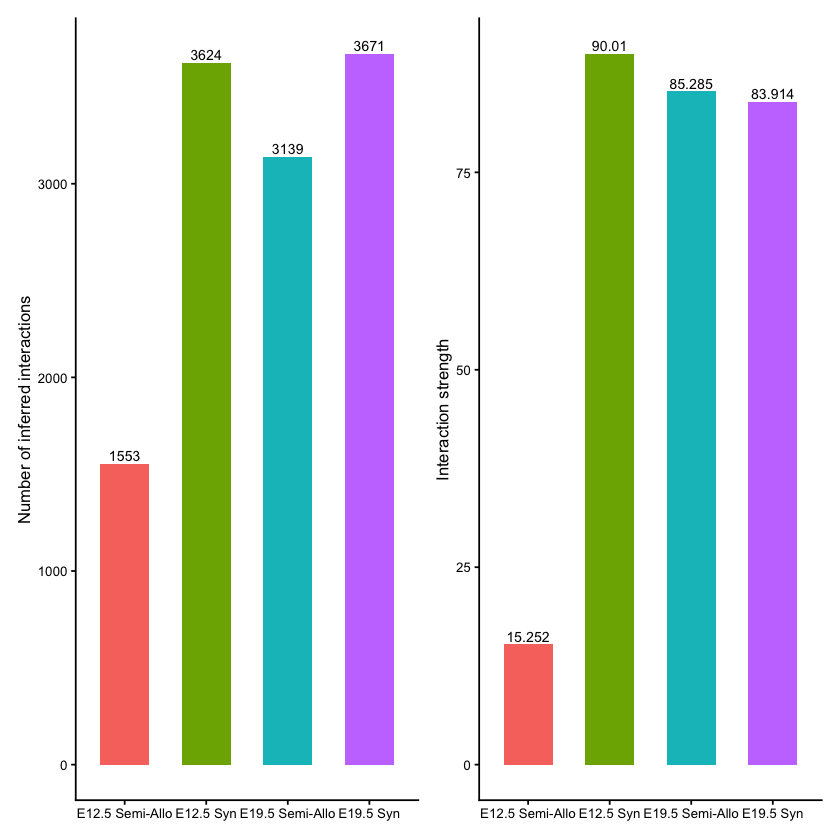

In [81]:
gg1 <- compareInteractions(CellChat, show.legend = F, group = c(1,2,3,4))
gg2 <- compareInteractions(CellChat, show.legend = F, group = c(1,2,3,4), measure = "weight")

ggsave(
  filename = "Interactions Bar Plot.jpeg", 
  plot = last_plot(),
  width = 12, 
  height = 8, 
  dpi = 600  
)

Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways

Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways

Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways

Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways



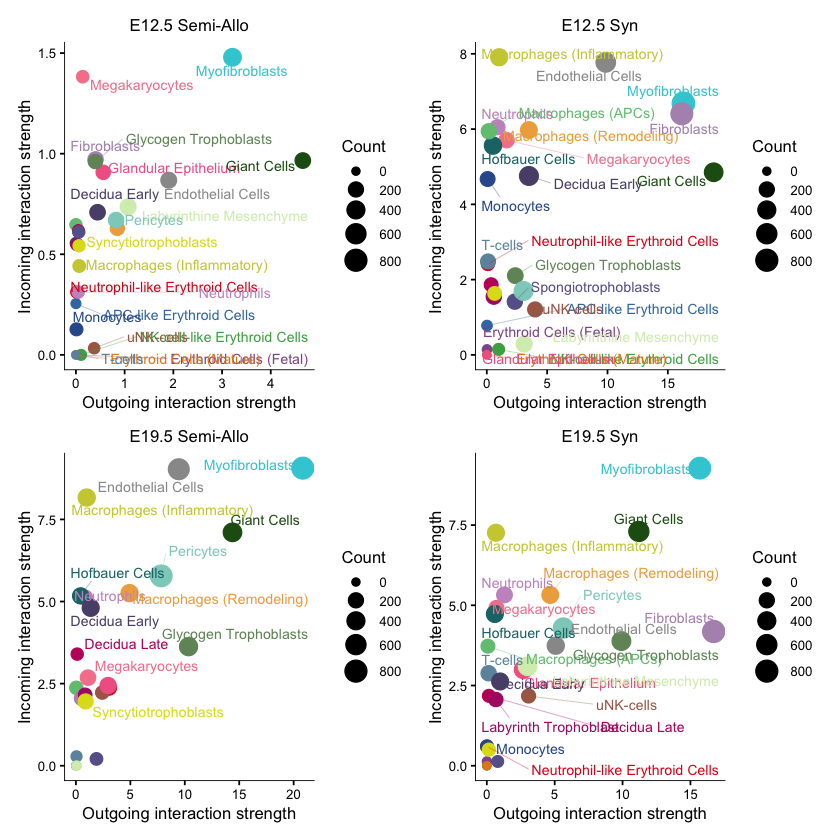

In [86]:
object.list <- list()

for (dataset_name in names(CellChat@net)) {
  temp_chat <- CellChat 
  
  temp_chat@netP <- CellChat@netP[[dataset_name]]
  temp_chat@net  <- CellChat@net[[dataset_name]]
  
  if (is.list(CellChat@idents)) {
    temp_chat@idents <- CellChat@idents[[dataset_name]]
  }
  
  object.list[[dataset_name]] <- temp_chat
}

num.link <- sapply(object.list, function(x) {rowSums(x@net$count) + colSums(x@net$count)-diag(x@net$count)})
weight.MinMax <- c(min(num.link), max(num.link))

gg <- list()
for (i in 1:length(object.list)) {
  gg[[i]] <- netAnalysis_signalingRole_scatter(object.list[[i]], 
                                               title = names(object.list)[i], 
                                               weight.MinMax = weight.MinMax)
}

# Display all plots
patchwork::wrap_plots(plots = gg, ncol = 2)

ggsave(
  filename = "Interation Str Plots.jpeg", 
  plot = last_plot(),
  width = 12, 
  height = 11, 
  dpi = 600  
)

In [89]:
# install.packages("reticulate")
library(reticulate)
# py_install(packages = 'umap-learn')

Compute signaling network similarity for datasets 1 2 3 4 
Manifold learning of the signaling networks for datasets 1 2 3 4 
Classification learning of the signaling networks for datasets 1 2 3 4 
2D visualization of signaling networks from datasets 1 2 3 4 


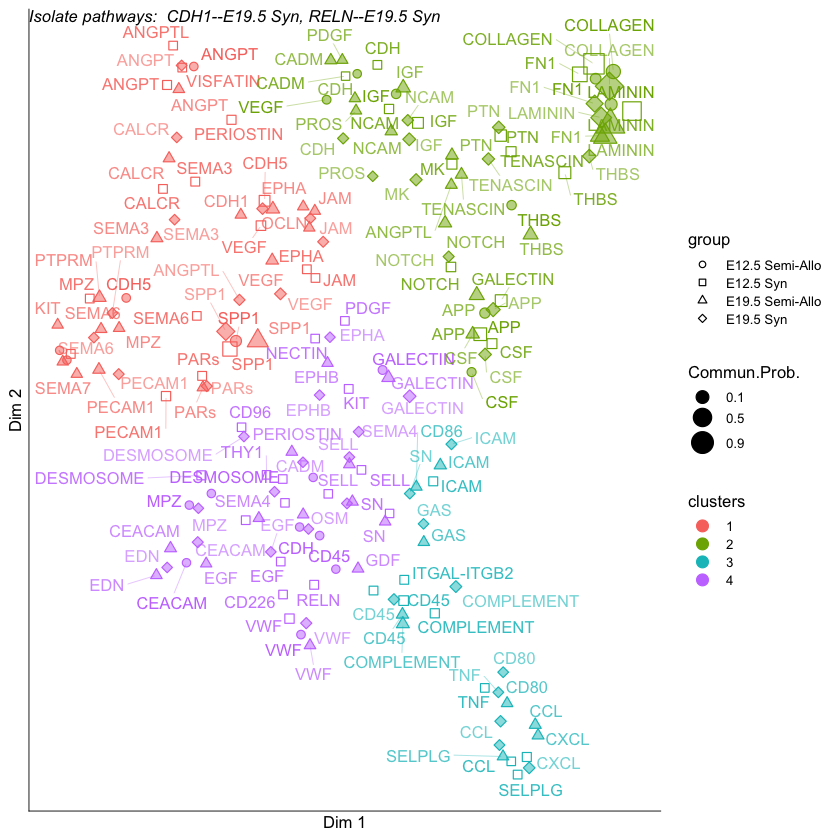

In [90]:
# Compute similarity based on functional network topology
CellChat <- computeNetSimilarityPairwise(CellChat, type = "functional")
CellChat <- netEmbedding(CellChat, type = "functional")
CellChat <- netClustering(CellChat, type = "functional")

# Visualize the functional embedding in a 2D space
netVisual_embeddingPairwise(CellChat, type = "functional", label.size = 3.5)

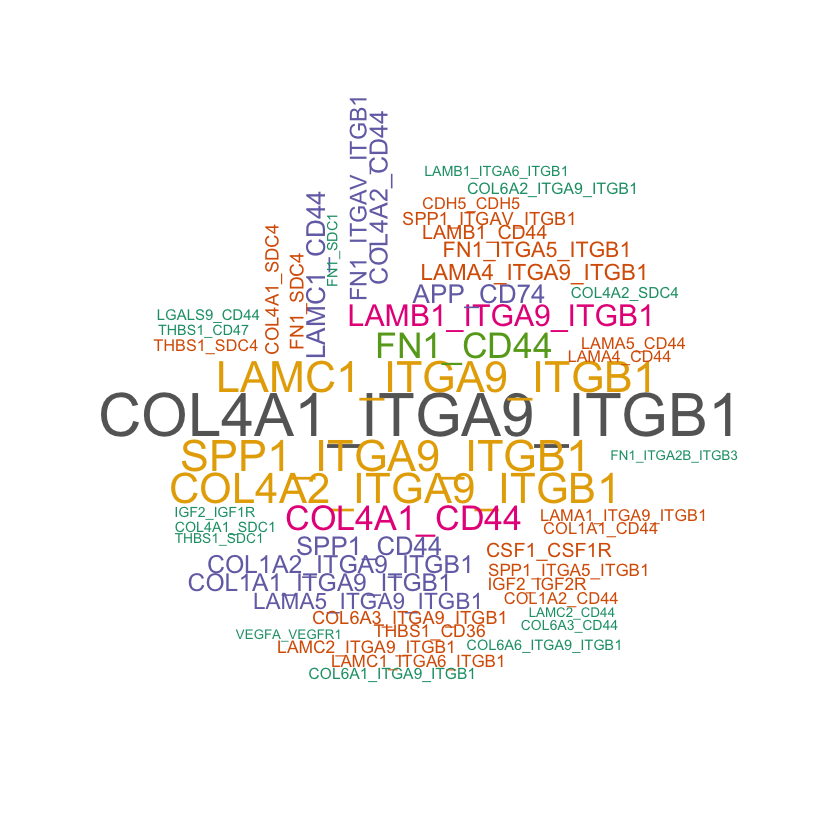

In [73]:
# Install and load the wordcloud package if you haven't already
# install.packages(c("wordcloud", "RColorBrewer"))
library(wordcloud)
library(RColorBrewer)
library(dplyr)

# 1. Load your differential interaction CSV (e.g., E19.5 Semi-Allo)
# Replace with the actual path to your CSV file
df <- read.csv("Significant_LR_Stats_Gestation Semi-Allo.csv")

# 2. Aggregate the probabilities by Ligand-Receptor interaction name
lr_weights <- df %>%
  group_by(interaction_name) %>%
  summarize(total_prob = sum(prob)) %>%
  arrange(desc(total_prob))

# 3. Generate the Wordcloud
set.seed(123) # For reproducibility
wordcloud(words = lr_weights$interaction_name, 
          freq = lr_weights$total_prob, 
          min.freq = 0.05,            # Adjust this threshold to filter out rare pairs
          max.words = 50,             # Top 50 interactions
          random.order = FALSE,       # Largest words in the center
          colors = brewer.pal(8, "Dark2"),
          scale = c(3, 0.5))          # Adjust word size scale

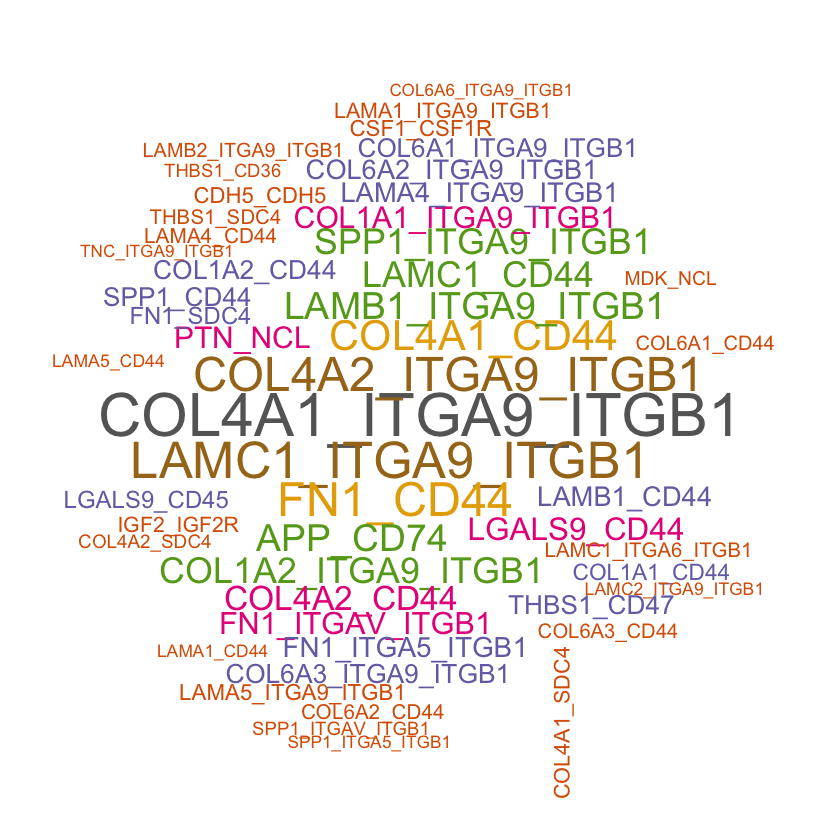

In [74]:
# Install and load the wordcloud package if you haven't already
# install.packages(c("wordcloud", "RColorBrewer"))
library(wordcloud)
library(RColorBrewer)
library(dplyr)

# 1. Load your differential interaction CSV (e.g., E19.5 Semi-Allo)
# Replace with the actual path to your CSV file
df <- read.csv("Significant_LR_Stats_Gestation Syn.csv")

# 2. Aggregate the probabilities by Ligand-Receptor interaction name
lr_weights <- df %>%
  group_by(interaction_name) %>%
  summarize(total_prob = sum(prob)) %>%
  arrange(desc(total_prob))

# 3. Generate the Wordcloud
set.seed(123) # For reproducibility
wordcloud(words = lr_weights$interaction_name, 
          freq = lr_weights$total_prob, 
          min.freq = 0.05,            # Adjust this threshold to filter out rare pairs
          max.words = 50,             # Top 50 interactions
          random.order = FALSE,       # Largest words in the center
          colors = brewer.pal(8, "Dark2"),
          scale = c(3, 0.5))          # Adjust word size scale

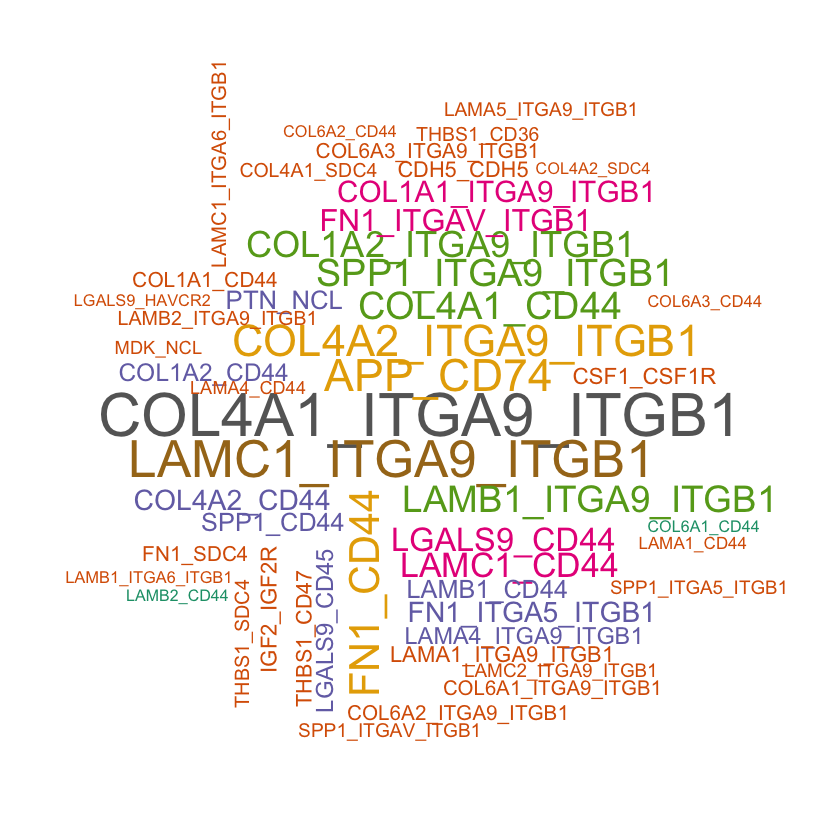

In [75]:
# Install and load the wordcloud package if you haven't already
# install.packages(c("wordcloud", "RColorBrewer"))
library(wordcloud)
library(RColorBrewer)
library(dplyr)

# 1. Load your differential interaction CSV (e.g., E19.5 Semi-Allo)
# Replace with the actual path to your CSV file
df <- read.csv("Significant_LR_Stats_Pregnancy E12.5.csv")

# 2. Aggregate the probabilities by Ligand-Receptor interaction name
lr_weights <- df %>%
  group_by(interaction_name) %>%
  summarize(total_prob = sum(prob)) %>%
  arrange(desc(total_prob))

# 3. Generate the Wordcloud
set.seed(123) # For reproducibility
wordcloud(words = lr_weights$interaction_name, 
          freq = lr_weights$total_prob, 
          min.freq = 0.05,            # Adjust this threshold to filter out rare pairs
          max.words = 50,             # Top 50 interactions
          random.order = FALSE,       # Largest words in the center
          colors = brewer.pal(8, "Dark2"),
          scale = c(3, 0.5))          # Adjust word size scale

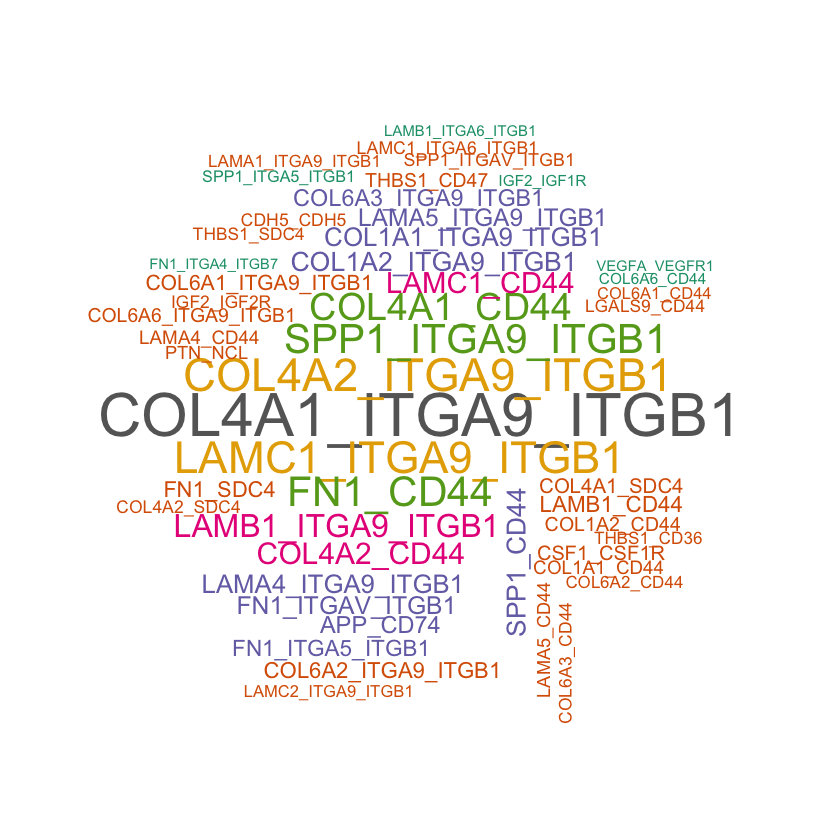

In [76]:
# Install and load the wordcloud package if you haven't already
# install.packages(c("wordcloud", "RColorBrewer"))
library(wordcloud)
library(RColorBrewer)
library(dplyr)

# 1. Load your differential interaction CSV (e.g., E19.5 Semi-Allo)
# Replace with the actual path to your CSV file
df <- read.csv("Significant_LR_Stats_Pregnancy E19.5.csv")

# 2. Aggregate the probabilities by Ligand-Receptor interaction name
lr_weights <- df %>%
  group_by(interaction_name) %>%
  summarize(total_prob = sum(prob)) %>%
  arrange(desc(total_prob))

# 3. Generate the Wordcloud
set.seed(123) # For reproducibility
wordcloud(words = lr_weights$interaction_name, 
          freq = lr_weights$total_prob, 
          min.freq = 0.05,            # Adjust this threshold to filter out rare pairs
          max.words = 50,             # Top 50 interactions
          random.order = FALSE,       # Largest words in the center
          colors = brewer.pal(8, "Dark2"),
          scale = c(3, 0.5))          # Adjust word size scale